In [2]:
print("AirFly Insights Final Analysis Loaded Successfully!")

AirFly Insights Final Analysis Loaded Successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv("data/flights_cleaned.csv", low_memory=False)

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,MONTH_NAME,DAY_NAME,DEPARTURE_HOUR,ROUTE
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,NaN,0.0,0.0,0.0,0.0,0.0,April,Tuesday,13,FWA-DTW
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,NaN,0.0,0.0,0.0,0.0,0.0,January,Saturday,19,LAS-SEA
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,NaN,0.0,0.0,0.0,0.0,0.0,July,Wednesday,6,OAK-SEA
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,NaN,0.0,0.0,0.0,152.0,0.0,May,Tuesday,8,STL-DAL
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,NaN,0.0,0.0,0.0,0.0,0.0,July,Monday,10,IAH-HNL


## 1. Overview of Flight Data
This section provides a general understanding of the flight dataset. 
It shows how flight activity is distributed across different months.

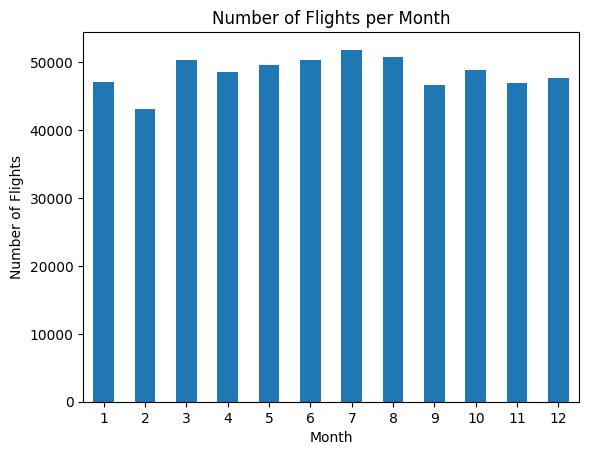

In [13]:
# Flights per month
monthly_flights = df["MONTH"].value_counts().sort_index()

plt.figure()
monthly_flights.plot(kind='bar')
plt.title("Number of Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

## 2. Flight Delay Analysis
This section analyzes how flight delays vary across months and airlines. 
It helps identify patterns in flight delays and highlights which airlines experience higher delays.

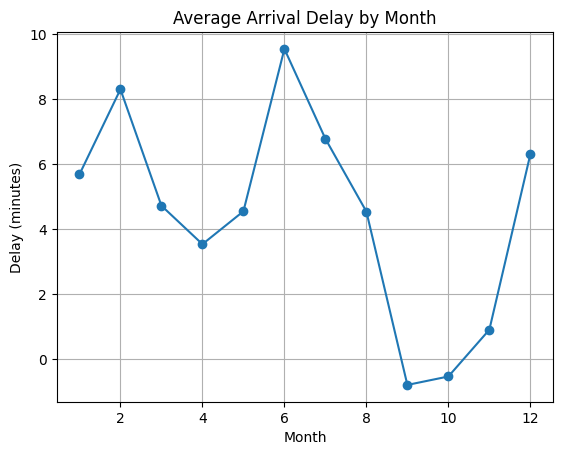

In [14]:
# Average delay per month
monthly_delay = df.groupby("MONTH")["ARRIVAL_DELAY"].mean()

plt.figure()
monthly_delay.plot(kind='line', marker='o')
plt.title("Average Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Delay (minutes)")
plt.grid()
plt.show()

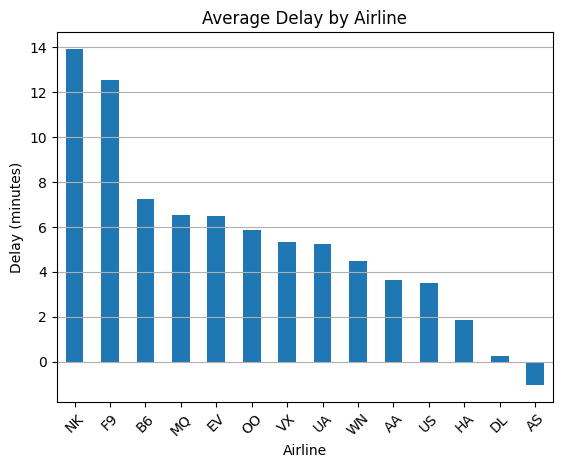

In [15]:
# Delay by airline
airline_delay = df.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values(ascending=False)

plt.figure()
airline_delay.plot(kind='bar')
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## 3. Cancellation Analysis
This section explores the reasons behind flight cancellations. 
It helps understand the main factors affecting flight operations.

In [7]:
# Filter cancelled flights
cancelled_flights = df[df["CANCELLED"] == 1]

# Count reasons
cancellation_counts = cancelled_flights["CANCELLATION_REASON"].value_counts()

# Map codes
reason_map = {
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}

cancellation_counts.index = cancellation_counts.index.map(reason_map)

# Convert to dataframe
cancellation_counts = cancellation_counts.reset_index()
cancellation_counts.columns = ["Reason", "Count"]

# Pie chart
fig = px.pie(
    cancellation_counts,
    names="Reason",
    values="Count",
    title="Flight Cancellation Reasons"
)

fig.show()

## 4. Airport Analysis
This section identifies the busiest airports based on flight volume. 
It highlights major hubs with high traffic.

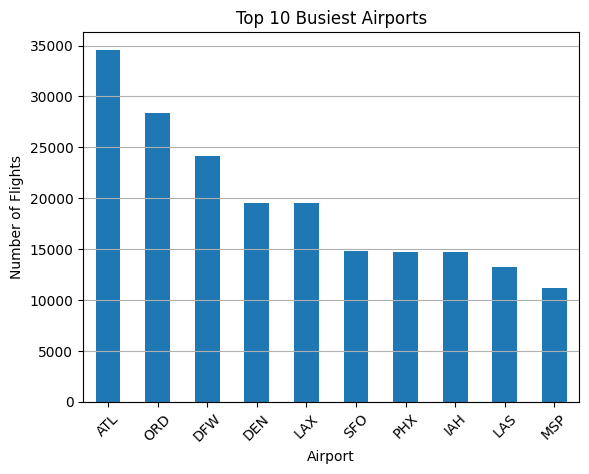

In [18]:
# Top airports
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(10)

plt.figure()
top_airports.plot(kind='bar')
plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## 5. Seasonal (Winter) Impact
This section analyzes how winter months affect flight delays and cancellations. 
It compares winter performance with overall trends.

In [9]:
# Winter months
winter_df = df[df["MONTH"].isin([12,1,2])]

# Metrics
winter_delay = winter_df["ARRIVAL_DELAY"].mean()
overall_delay = df["ARRIVAL_DELAY"].mean()

winter_cancel_rate = winter_df["CANCELLED"].mean()
winter_cancel_percent = winter_cancel_rate * 100

print("Winter Avg Delay:", winter_delay)
print("Overall Avg Delay:", overall_delay)
print("Winter Cancellation Rate:", winter_cancel_rate)
print("Winter Cancellation Percentage:", winter_cancel_percent)

Winter Avg Delay: 6.709740167436014
Overall Avg Delay: 4.454959012387057
Winter Cancellation Rate: 0.029993613747859155
Winter Cancellation Percentage: 2.9993613747859156


## Conclusion

The analysis shows that flight delays and cancellations are influenced by multiple factors such as airline operations, weather conditions, and airport traffic.

Winter months experience higher delays and cancellation rates compared to the overall average, indicating the significant impact of seasonal conditions on flight performance.

This study provides useful insights into airline operations and can help improve planning and decision-making.